<a href="https://colab.research.google.com/github/hombremono873/Cuadernos_colab/blob/main/Diego_Roa_Omar_torres_Actividad5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto: Predicción de Readmisión Hospitalaria en Pacientes con Diabetes mediante Modelos de Machine Learning**
### Asignatura: Ciencia de Datos

---

**Estudiantes:** Omar A Torres, Diego Alejandro Roa Lara
**Universidad:** Santo Tomas

**Docente:** Diego Ricardo Paez Arcila
**Fecha de entrega:** 12 de Septiembre del 2026

## **1.Introduccion**

La readmision hospitalaria en pacientes con diabetes es un problema critico tanto para la calidad de vida de los pacientes como para los costos del sistema de salud. Cuando un paciente diabetico regresa al hospital en menos de 30 dias despues de haber sido dado de alta, esto suele indicar que el tratamiento inicial no fue suficiente o que faltaron mecanismos de seguimiento adecuados.

Este proyecto busca responder una pregunta central: **es posible predecir, a partir de los datos clinicos disponibles durante la hospitalizacion, si un paciente sera readmitido despues de haber sido atendido antes o depues de 30 dias?**

Para responderla, se trabajo con un dataset de mas de 100,000 registros clinicos provenientes de 130 hospitales de Estados Unidos, entre 1999 y 2008, y se entrenaron distintos modelos de clasificacion para evaluar su capacidad predictiva.

##**2. Problema**



Se plantea un problema de **clasificacion binaria supervisada**, donde el objetivo es predecir si un paciente diabetico sera readmitido al hospital, sin importar el numero de dias transcurridos hasta la readmision.

La variable original readmitted, que en el dataset cuenta con tres categorias (menor a 30, mayor a 30 y No), fue transformada en una variable binaria:

- **Readmitido**: el paciente fue readmitido en algun momento, ya sea en menos o en mas de 30 dias
- **No readmitido**: no hay registro de una readmision posterior

Esta unificacion busca fortalecer la señal predictiva del modelo, ya que las clases menor a 30 y mayor a 30 comparten patrones clinicos similares y son dificiles de separar entre si, mientras que la diferencia relevante desde el punto de vista clinico y operativo es identificar si el paciente regresara al hospital o no.

Formalmente, se busca aprender una funcion f(X) que, a partir de un vector de variables de entrada X (edad, tiempo en hospital, numero de procedimientos, medicamentos administrados, diagnosticos, entre otras), prediga la categoria binaria Y de readmision correspondiente.

El reto principal sigue siendo el **desbalance de clases**, ya que la proporcion de pacientes readmitidos frente a los no readmitidos no es equitativa, lo que exige priorizar metricas como recall y AUC por encima del accuracy general.

## **3. Dataset**



El proyecto utiliza el dataset **Diabetes 130 US Hospitals (1999-2008)**, disponible en Kaggle, que contiene informacion clinica de mas de **100,000 encuentros hospitalarios** de pacientes diabeticos, recolectados en 130 hospitales de Estados Unidos durante un periodo de diez años.

Cada registro representa la hospitalizacion de un paciente e incluye variables de tres tipos:

- **Demograficas**: edad, genero, raza
- **Clinicas del encuentro**: tiempo de estancia en el hospital, numero de procedimientos de laboratorio, numero de procedimientos medicos, numero de medicamentos administrados, diagnosticos (diag_1, diag_2, diag_3)
- **Historial previo**: numero de visitas ambulatorias, de urgencias y de hospitalizaciones en el año anterior al encuentro
- **Medicacion especifica**: 24 variables que indican si se prescribio o modifico la dosis de distintos medicamentos para la diabetes (metformina, insulina, entre otros)

La variable objetivo original, readmitted, fue transformada en una variable binaria (**Readmitido** / **No readmitido**), como se explico en la formulacion del problema.

Un primer analisis de la distribucion de esta variable ya anticipa uno de los principales retos del proyecto: la proporcion de pacientes readmitidos es considerablemente menor que la de no readmitidos, lo que confirma que se trata de un problema con **desbalance de clases**.

**Enlace al dataset**: https://www.kaggle.com/datasets/razanihababdellatif/diabetes-hospital-readmission-dataset

## **4. Dificultad del dataset**

Este dataset es ampliamente conocido en la comunidad de ciencia de datos por presentar un **techo de desempeño dificil de superar**, sin importar el modelo o la tecnica utilizada. Distintos estudios y notebooks publicados reportan consistentemente valores de AUC alrededor de **0.65 a 0.70**, incluso al probar modelos avanzados como Random Forest, XGBoost o redes neuronales. Esta dificultad se debe a varios factores estructurales del propio dataset:

- **Desbalance de clases**: la proporcion de pacientes readmitidos es considerablemente menor que la de no readmitidos, lo que hace que los modelos tiendan a favorecer la clase mayoritaria si no se aplican tecnicas de balanceo.

- **Alta cardinalidad y valores faltantes**: variables como medical_specialty y payer_code tienen decenas de categorias distintas y una gran cantidad de valores no registrados, lo que limita su aporte real al poder predictivo del modelo.

- **Codigos de diagnostico sin agrupar**: las variables diag_1, diag_2 y diag_3 utilizan codigos ICD-9, con cientos de valores posibles. Si no se agrupan en categorias clinicas mas amplias (circulatorio, respiratorio, digestivo, entre otras), el modelo no logra extraer patrones utiles de esta informacion.

- **Factores externos no capturados**: si un paciente es readmitido o no depende tambien de variables que el dataset no registra, como el acceso a atencion medica posterior al alta, la situacion socioeconomica o el apoyo familiar, lo cual introduce un limite inherente a la capacidad predictiva de cualquier modelo.

Por esta razon, obtener resultados similares a los reportados en la literatura, en lugar de ser una limitacion, es evidencia de que la metodologia aplicada es **correcta y consistente** con el estado del arte para este problema.

**Enlace de estudio académico**: https://sciencescholar.us/journal/index.php/ijhs/article/view/15189

## **5. Preparación y limpieza de los datos**

Antes de entrenar los modelos, el dataset requirio varios procesos de limpieza y transformacion, dado que contenia valores faltantes ocultos, columnas sin valor predictivo y riesgo de fuga de informacion.

### **Deteccion de valores faltantes ocultos**

Al inspeccionar el dataset con df.info(), todas las columnas aparentaban estar completas. Sin embargo, el dataset utiliza el caracter **signo de interrogacion** como marcador de valor faltante en columnas como weight, payer_code, medical_specialty, race, diag_1, diag_2 y diag_3. Estos valores fueron reemplazados por NaN para poder identificarlos y tratarlos correctamente.


### **Eliminacion de columnas sin valor predictivo o con demasiados datos faltantes**

- **encounter_id y patient_nbr**: son identificadores unicos, no aportan informacion clinica.
- **weight**: aproximadamente 97 por ciento de valores faltantes, por lo que imputarla introduciria mas ruido que valor.
- **payer_code y medical_specialty**: alto porcentaje de valores faltantes y demasiadas categorias distintas.
- **diag_1, diag_2 y diag_3**: se eliminaron como columnas individuales, apoyandose en su lugar en la variable **number_diagnoses**, que resume la cantidad de diagnosticos registrados.


### **Prevencion de fuga de informacion (data leakage)**

Un mismo paciente puede aparecer varias veces en el dataset si tuvo mas de una hospitalizacion. Para evitar que el modelo aprenda patrones asociados a un paciente especifico en lugar de patrones clinicos generales, se conservó únicamente **el primer encuentro de cada paciente**.


### **Eliminacion de filas con valores nulos criticos**

Se eliminaron las filas donde la variable **race** era nula, al representar un porcentaje bajo del total y no ser posible imputarla de forma confiable.

### **Transformación de variables categoricas**

- **Variables ordinales (mapeo numerico secuencial)**: age (rangos de edad mapeados de 0 a 9) y A1Cresult (resultado de hemoglobina glicosilada, mapeado de 0 a 3).
- **Variables nominales (One Hot Encoding)**: race, gender, max_glu_serum, change, diabetesMed.
- **Medicamentos (One Hot Encoding, 23 variables)**: metformin, insulin, glipizide, pioglitazone, entre otras, cuyos valores originales eran No, Steady, Up y Down.

## **6. Modelos y metodología**


Se entrenaron y compararon tres algoritmos de clasificacion, elegidos para contrastar un modelo simple e interpretable frente a modelos de ensamble mas complejos:

- **Regresion Logistica**: modelo base e interpretable, util como punto de referencia.
- **Random Forest**: modelo de ensamble basado en multiples arboles de decision
- **Gradient Boosting**: modelo de ensamble secuencial, que corrige iterativamente los errores de los arboles anteriores.
- **RedNeuronal** Red Neuronal (MLP): perceptrón multicapa, una capa de entrda(68 variables) 2 capas ocultas(funcion de activación **RLUu**) y una salida con funcion de activación(**simoidea**), para capturar relaciones no lineales.
**Validacion**: los datos se dividieron en entrenamiento y prueba (70/30), utilizando **estratificacion** para mantener la proporcion original de clases en ambos conjuntos.

**Manejo del desbalance**: los tres modelos se entrenaron con **class_weight balanceado**, ya que la clase de pacientes readmitidos es minoritaria frente a la de no readmitidos.

**Metricas priorizadas**: dado el desbalance de clases, el accuracy general no es suficiente para evaluar el desempeño real del modelo. Se priorizaron:

- **F1-score** de la clase minoritaria, que equilibra precision y recall
- **ROC-AUC**, que mide la capacidad del modelo para discriminar entre pacientes readmitidos y no readmitidos, sin depender de un umbral fijo

Ademas, para el modelo con mejor desempeño (Gradient Boosting) se aplico **GridSearchCV** para la optimizacion de hiperparametros, y se ajusto el umbral de decision de 0.5 a 0.40, priorizando la deteccion de casos reales de readmision sobre la precision general.

## **7. Inclusion de librerías**

In [1]:
import sys

!{sys.executable} -m pip install -q tensorflow

# **Librerías de Scikit-learn para preprocesamiento y modelos**

In [25]:
"""
Librerías de Scikit-learn para preprocesamiento y modelos

"""
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

### **Librerías para Redes Neuronales (TensorFlow/Keras)**

Estas librerías se utilizan para la construcción, compilación y entrenamiento de la Red Neuronal (MLP), así como para la evaluación de sus métricas.

In [27]:
"""
   Librerías de TensorFlow/Keras para Redes Neuronales
"""
from tensorflow.keras import layers, Sequential, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC, Precision, Recall
from tensorflow.keras.optimizers import Adam

### **Librerías para Manipulación y Visualización de Datos**

Estas son librerías generales para el manejo de datos (Pandas, NumPy) y para la creación de gráficos (Matplotlib, Seaborn).

In [26]:
"""
Librerías generales para manipulación y visualización de datos
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Librerías para Utilidades del Entorno

Estas librerías se utilizan para la interacción con el sistema operativo (archivos y directorios), y para funcionalidades específicas de Google Colab y Kaggle.

In [5]:
# Librerías para utilidades y entorno (OS, Colab, Kaggle)
import os
from google.colab import files
import kagglehub

## **8. Lectura y analisis global del dataset**

In [6]:
# Download latest version
path = kagglehub.dataset_download("razanihababdellatif/diabetes-hospital-readmission-dataset")
print("Path to dataset files:", path)

archivo=os.path.join(path,"diabetic_data.csv")
df = pd.read_csv(archivo)

100%|██████████| 3.16M/3.16M [00:00<00:00, 131MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/razanihababdellatif/diabetes-hospital-readmission-dataset/versions/1


## **8.1 Inspección global del dataset**

In [7]:
""""
   Inspeccion global tipo de datos
"""
df = pd.read_csv(archivo)
df.sample(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
16647,62186136,597456,Caucasian,Female,[90-100),?,1,3,7,3,...,No,No,No,No,No,No,No,No,Yes,NO
78139,238325064,86318163,Caucasian,Female,[60-70),?,1,1,7,2,...,No,Down,No,No,No,No,No,Ch,Yes,NO
69493,197669988,86342967,Caucasian,Female,[40-50),?,1,2,7,2,...,No,No,No,No,No,No,No,No,No,>30
51975,154368288,113697108,Caucasian,Male,[70-80),?,2,1,1,7,...,No,No,No,No,No,No,No,Ch,Yes,>30
42883,132299262,79766622,Caucasian,Female,[60-70),?,3,6,1,4,...,No,Down,No,No,No,No,No,Ch,Yes,NO


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## **8.2 Analisis global y tipo de variables**

El dataset esta compuesto por **101,766 registros y 50 columnas**, con un uso de memoria de aproximadamente 38.8 MB, distribuidas en **13 variables numericas** y **37 variables categoricas**.


**Hallazgo importante**: aunque la mayoria de columnas aparecen como completas (101,766 valores non-null), este resultado es enganoso. El dataset utiliza el caracter **signo de interrogacion** como marcador de valor faltante en columnas como weight, payer_code, medical_specialty, race, diag_1, diag_2 y diag_3. Como pandas interpreta este simbolo como un texto valido y no como un valor nulo, estas ausencias no se detectan con isnull() ni se reflejan en el conteo de non-null.


Por esta razon, antes de continuar, es necesario convertir explicitamente estos marcadores en NaN, de modo que puedan identificarse y tratarse correctamente en los pasos de limpieza posteriores.

In [9]:
"""
   Se encontró campos vacíos con el caracter?, los reemplazamos por NaN
"""
df = df.replace("?", np.nan)
df.sample(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
97018,383219426,138105365,Caucasian,Male,[50-60),NaN,1,1,7,4,...,No,Up,No,No,No,No,No,Ch,Yes,<30
48037,147085776,74006928,Caucasian,Male,[60-70),NaN,1,1,7,5,...,No,Down,No,No,No,No,No,Ch,Yes,>30
57864,164586834,90794925,Caucasian,Male,[60-70),NaN,2,1,7,3,...,No,Steady,No,No,No,No,No,Ch,Yes,<30
72535,212400408,67434102,Caucasian,Male,[70-80),NaN,1,1,7,3,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
54829,159071118,23189139,Caucasian,Female,[80-90),NaN,3,23,1,8,...,No,Down,No,No,No,No,No,Ch,Yes,>30


## **8.3 Análisis estadístico global**


El analisis con df.describe() muestra que las variables numericas se encuentran en escalas muy distintas, lo cual afecta principalmente a la Regresion Logistica por ser sensible a la escala, aunque no tanto a los modelos de ensamble como Random Forest o Gradient Boosting.

**Identificadores sin valor predictivo**

encounter_id y patient_nbr presentan valores en el orden de millones. Son unicamente identificadores de registro, por lo que deben excluirse del modelo.

**Rangos dispares entre variables clinicas**

num_lab_procedures alcanza hasta 132, mientras que num_procedures llega solo hasta 6. Sin un escalado adecuado, las variables con valores mas grandes podrian dominar el modelo por su magnitud, no por su relevancia real.

**Variables con posibles outliers**

number_emergency, number_outpatient y number_inpatient muestran medias cercanas a 0 (0.20, 0.37 y 0.64 respectivamente) frente a maximos muy altos (76, 42 y 21). Esto indica que la mayoria de pacientes tiene valores bajos, mientras unos pocos casos extremos elevan el rango, un patron tipico en datos de conteo hospitalario.

**Acciones a tomar**

1. Excluir encounter_id y patient_nbr como variables predictoras
2. Aplicar StandardScaler a las variables numericas
3. Revisar los outliers en number_emergency, number_outpatient y number_inpatient

In [10]:
"""
  Estadisticos globales
  """
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## **8.4 Proceso de limpieza y transformación de variables**

In [28]:
"""
 analisis porcentual de variable con valores nulos

"""

def porcentaje_nulos(df):
  porcentaje_nulos1 = df.isnull().mean() * 100
  resultado = porcentaje_nulos1[porcentaje_nulos1 > 0].sort_values(ascending=False)
  print(resultado.map(lambda x: f"{x:.2f}%"))
porcentaje_nulos(df)

Series([], dtype: float64)


In [29]:
"""
   Función para limpiar el dataset
"""

def limpiar_df(df):
    df_processed = df.copy()

    # Eliminar columnas con muchos valores faltantes o sin valor predictivo
    columnas_a_eliminar_inicial = [
        'weight', 'payer_code', 'medical_specialty',
        'diag_1', 'diag_2', 'diag_3'
    ]
    # Filtra las columnas para eliminar solo las que existen en el DataFrame
    cols_to_drop_initial_existing = [col for col in columnas_a_eliminar_inicial if col in df_processed.columns]
    df_processed = df_processed.drop(columns=cols_to_drop_initial_existing, errors='ignore')

    # Rellenar valores faltantes (identificados como '?') en columnas específicas
    if 'max_glu_serum' in df_processed.columns:
        df_processed['max_glu_serum'] = df_processed['max_glu_serum'].fillna("No realizado")
    if 'A1Cresult' in df_processed.columns:
        df_processed['A1Cresult'] = df_processed['A1Cresult'].fillna("No realizado")

    # Ordenar y eliminar duplicados por 'patient_nbr', manteniendo el primer encuentro
    # Esta paso requiere que 'encounter_id' y 'patient_nbr' estén presentes.
    if 'encounter_id' in df_processed.columns and 'patient_nbr' in df_processed.columns:
        df_processed = df_processed.sort_values('encounter_id')
        df_processed = df_processed.drop_duplicates(subset='patient_nbr', keep='first')
    elif 'patient_nbr' in df_processed.columns:
        df_processed = df_processed.drop_duplicates(subset='patient_nbr', keep='first')


    # Eliminar filas donde 'race' es nulo
    if 'race' in df_processed.columns:
        df_processed = df_processed.dropna(subset=['race'])

    # Eliminar los identificadores que ya cumplieron su función
    cols_to_drop_ids = ['encounter_id', 'patient_nbr']
    cols_to_drop_ids_existing = [col for col in cols_to_drop_ids if col in df_processed.columns]
    df_processed = df_processed.drop(columns=cols_to_drop_ids_existing, errors='ignore')

    return df_processed
df = df.copy()
df = limpiar_df(df)
porcentaje_nulos(df)

Series([], dtype: float64)


In [30]:
"""
 Funcion para transformar variables categoricas a numero
"""
def transformar_ordinales(df):
    # Mapeo ordenado para la edad ([0-10) = 0, [10-20) = 1, etc.)
    mapa_edad = {
        '[0-10)': 0, '[10-20)': 1, '[20-30)': 2, '[30-40)': 3, '[40-50)': 4,
        '[50-60)': 5, '[60-70)': 6, '[70-80)': 7, '[80-90)': 8, '[90-100)': 9
    }
    # Solo transforma si age todavia esta en formato texto (evita nulos si se ejecuta dos veces)
    if 'age' in df.columns and df['age'].dtype == object:
        df['age'] = df['age'].map(mapa_edad)

    # Mapeo ordenado para  niveles de azucar en sangre: A1Cresult (datos nulos se rellenó con "No realizado")
    mapa_a1c = {'No realizado': 0, 'Norm': 1, '>7': 2, '>8': 3}
    if 'A1Cresult' in df.columns and df['A1Cresult'].dtype == object:
        df['A1Cresult'] = df['A1Cresult'].map(mapa_a1c)
    return df

def transformar_medicamentos_y_nominales(df):
    # Lista de medicamentos
    medicamentos = [
        'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
        'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
        'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
        'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
        'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
    ]
    # Otras variables nominales generales (incluyendo payer_code, medical_specialty y los diagnósticos)
    otras_nominales = [
        'race', 'gender', 'change', 'diabetesMed', 'max_glu_serum',
        'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3'
    ]
    # Combinar todas las columnas que queremos pasar a dummies de forma segura
    cols_a_procesar = medicamentos + otras_nominales
    cols_existentes = [col for col in cols_a_procesar if col in df.columns]  #Se agrega columna a lista si existe
    if cols_existentes:
        df = pd.get_dummies(df, columns=cols_existentes, drop_first=True, dtype=int)
    return df

def transformar_target(df):
    # Mapeo binario: 0 = No readmitido, 1 = Readmitido (tanto >30 como <30)
    mapping = {'NO': 0, '>30': 1, '<30': 1}
    # Solo transforma si readmitted todavia esta en formato texto
    if 'readmitted' in df.columns and df['readmitted'].dtype == object:
        df['readmitted'] = df['readmitted'].map(mapping)
    return df

In [31]:
"""
 Llamado a las funciones de transformación

"""

df = transformar_ordinales(df)
df = transformar_medicamentos_y_nominales(df)
df = transformar_target(df)

df = df.drop(columns=['encounter_id', 'patient_nbr'], errors='ignore')

# 5. Verificación final del resultado
print("¡Proceso de preprocesamiento completado!\n")
print("Dimensiones finales del DataFrame:", df.shape)
print("Primeras 5 columnas del resultado:", df.columns[:5].tolist())
df.sample(5)

¡Proceso de preprocesamiento completado!

Dimensiones finales del DataFrame: (69570, 69)
Primeras 5 columnas del resultado: ['age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital']


,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,race_Caucasian,race_Hispanic,race_Other,gender_Male,gender_Unknown/Invalid,change_No,diabetesMed_Yes,max_glu_serum_>300,max_glu_serum_No realizado,max_glu_serum_Norm
15292,6,3,18,1,5,32,6,19,0,0,...,1,0,0,1,0,1,1,0,1,0
90186,8,3,3,7,4,2,0,5,0,0,...,1,0,0,0,0,1,0,0,1,0
74339,6,3,6,1,2,62,2,21,0,0,...,0,0,0,0,0,0,1,0,1,0
12732,7,2,1,2,1,2,2,3,1,0,...,1,0,0,1,0,1,1,0,1,0
89138,5,3,1,1,1,9,4,14,0,0,...,1,0,0,0,0,1,1,0,1,0


In [32]:
"""
   Dimenciones del dataset despues de las transformaciones
"""
df.shape

(69570, 69)

In [33]:
"""
   Se escalizan los datos, se obtiene la variable objetivo y se dividen los datos
"""
if "readmitted" not in df.columns:
    raise ValueError("La columna 'readmitted' no existe en el dataset")
y = df["readmitted"]
X = df.drop(columns=["readmitted"])

# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

"""
   Los resultados de la escalización nos dice la calidad de la transformacion
"""
print("Datos escalados correctamente.")
print(f"Media de X_train_scaled: {X_train.mean():.4f}") # Debería ser cercana a 0
print(f"Desviación de X_train_scaled: {X_train.std():.4f}") # Debería ser cercana a 1


Datos escalados correctamente.
Media de X_train_scaled: -0.0000
Desviación de X_train_scaled: 0.9926


## **9. Distribución de la variable objetivo y análisis de la correlación de los predictores**

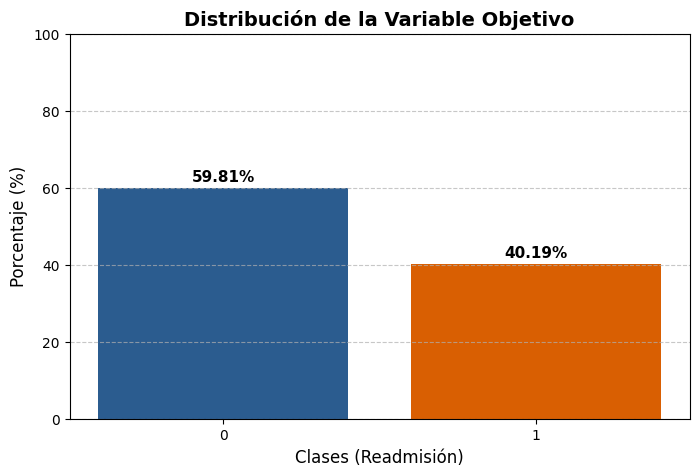

In [34]:
"""
   Distribucion de la variable objetivo
"""

# 1. Calcular los porcentajes (ahora con las 3 clases originales)
porcentajes = y_train.value_counts(normalize=True) * 100

# Crear la figura y la gráfica de barras

colores = ['#2b5c8f', '#d95f02', '#7570b3'][:len(porcentajes)]

plt.figure(figsize=(8, 5))
barras = plt.bar(porcentajes.index.astype(str), porcentajes.values, color=colores)

# Añadir las etiquetas de porcentaje encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 1,
             f'{altura:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Estilos y etiquetas
plt.title('Distribución de la Variable Objetivo', fontsize=14, fontweight='bold')
plt.xlabel('Clases (Readmisión)', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

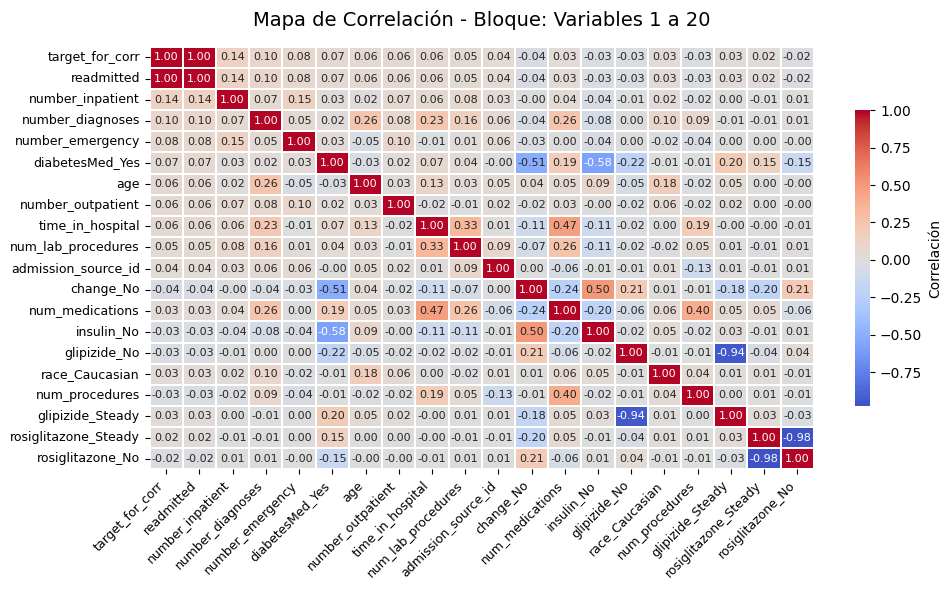

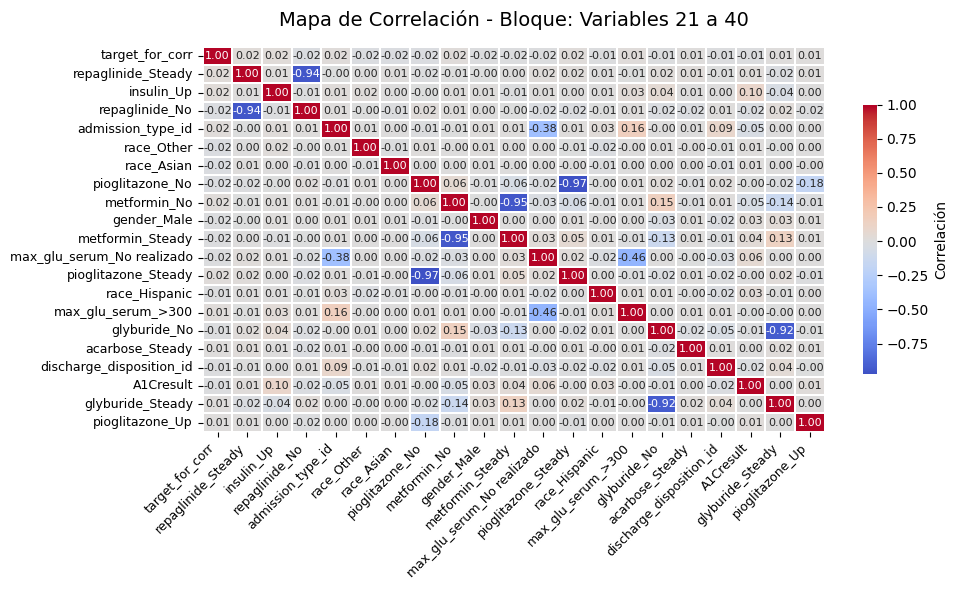

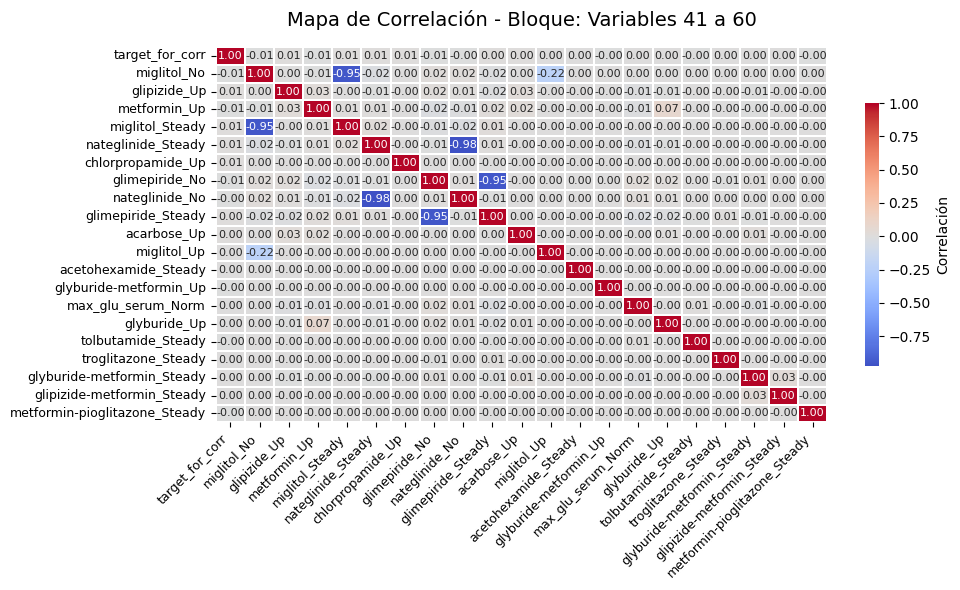

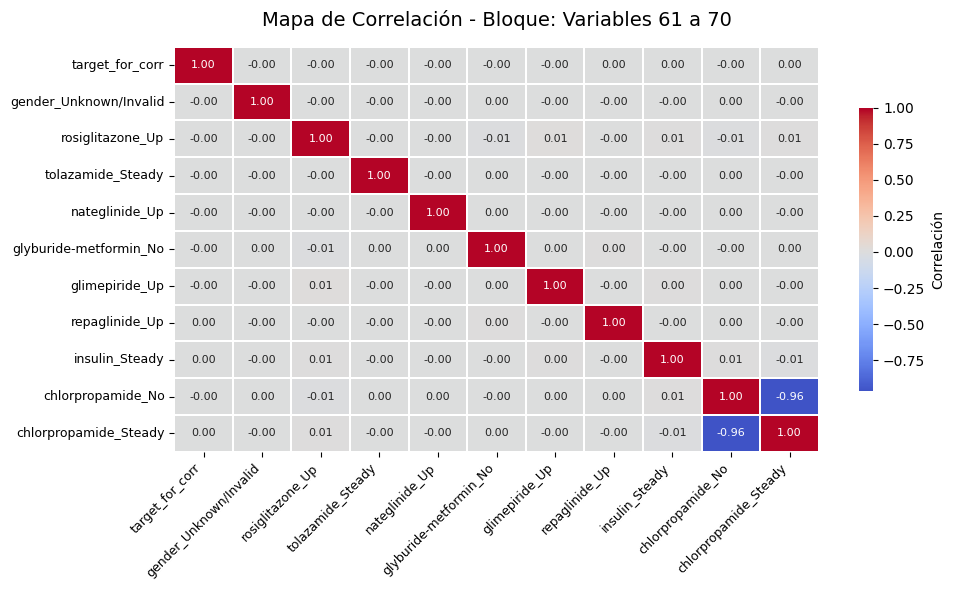

In [35]:
"""
   Mapa de correlación de los predictores
"""
TARGET_CORR_NAME = 'target_for_corr' # Nombre para la columna objetivo en la copia para correlación
TAMANO_BLOQUE = 20

# Esto asegura que el DataFrame original 'df' no sea modificado.
df_for_corr = df.copy()


# y crear la columna para el objetivo de la correlación.
if 'readmitted' in df_for_corr.columns:
    df_for_corr[TARGET_CORR_NAME] = df_for_corr['readmitted']
else:
    print("Advertencia: La columna 'readmitted' no se encontró en el DataFrame para el mapa de correlación.")
    TARGET_CORR_NAME = None # Indicar que no hay objetivo válido para la correlación.


if TARGET_CORR_NAME:
    df_numerico = df_for_corr.select_dtypes(include=['number']) # Obtener solo columnas numéricas de la copia

    if 'y_train' in df_numerico.columns:
        df_numerico = df_numerico.drop(columns=['y_train'])

    matriz_corr = df_numerico.corr()  # Calcular la matriz de correlación completa

    if TARGET_CORR_NAME in matriz_corr.columns:
        variables_ordenadas = matriz_corr[TARGET_CORR_NAME].abs().sort_values(ascending=False).index
    else:
        variables_ordenadas = matriz_corr.columns

    # Dividir las variables en bloques y graficarlos secuencialmente
    total_variables = len(variables_ordenadas)

    for i in range(0, total_variables, TAMANO_BLOQUE):
        # Obtener el subconjunto de variables para el bloque actual
        variables_bloque = variables_ordenadas[i : i + TAMANO_BLOQUE]

        # Asegurarse de que el objetivo esté en el bloque si es relevante y no está ya
        if TARGET_CORR_NAME and TARGET_CORR_NAME not in variables_bloque and TARGET_CORR_NAME in variables_ordenadas:
            variables_bloque = variables_bloque.insert(0, TARGET_CORR_NAME)

        matriz_bloque = matriz_corr.loc[variables_bloque, variables_bloque]

        plt.figure(figsize=(10, 6))

        sns.heatmap(
            matriz_bloque,
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt=".2f",
            annot_kws={"size": 8},
            linewidths=0.2,
            linecolor='white',
            cbar_kws={"shrink": .7, "label": 'Correlación'}
        )

        rango_actual = f"Variables {i+1} a {min(i + TAMANO_BLOQUE, total_variables)}"
        plt.title(f'Mapa de Correlación - Bloque: {rango_actual}', fontsize=14, pad=15)
        plt.xticks(rotation=45, ha='right', fontsize=9)
        plt.yticks(fontsize=9)

        plt.tight_layout()
        plt.show()

## **9.1 Analisis de correlacion**

El mapa de correlacion muestra dos patrones esperados, que no requieren eliminar variables:

**Correlacion individual debil con la variable objetivo**

La gran mayoria de variables presentan correlaciones muy bajas con readmitted (valores cercanos a 0.01 o -0.02). Esto no indica que las variables sean inutiles, ya que la correlacion de **Pearson solo captura relaciones lineales entre pares de variables**. Modelos como Random Forest y Gradient Boosting pueden capturar interacciones y relaciones no lineales que este analisis no detecta. Ademas, este hallazgo refuerza la idea central del proyecto: ninguna variable individual tiene poder predictivo fuerte, lo cual es consistente con el techo de desempeño reportado en la literatura.

**Correlacion alta entre categorias del mismo medicamento**

Se observan correlaciones muy altas (cercanas a -0.95 o -0.97) entre dummies como pioglitazone_No y pioglitazone_Steady, o metformin_No y metformin_Steady. Esto es un efecto esperado del One Hot Encoding: si un paciente tiene una categoria activa, automaticamente las demas categorias de la misma variable original son cero, generando correlacion negativa fuerte entre ellas. No representa una redundancia problematica entre variables distintas.

**Por que no se eliminan variables**

La Regresion Logistica utiliza penalizacion L1, que reduce automaticamente a cero los coeficientes de variables redundantes. En Random Forest y Gradient Boosting, la multicolinealidad entre variables no afecta la capacidad predictiva del modelo. Por esta razon, se conservaron todas las variables disponibles.

## **10. Modelos de machine learning**

## **10.1 Regresión logística**

In [19]:
"""
   Algoritmo de Regresión logistica, para problemas de clasificación.
"""
# Instanciar el modelo con balanceo automático de clases
modelo_rlg = LogisticRegression(
    class_weight='balanced',
    max_iter=1500, random_state=42,
    C = 0.1,      # Penalizamos
    penalty="l1",
    solver='saga')

# Entrenar el modelo
modelo_rlg.fit(X_train, y_train)

# Predecir
y_pred = modelo_rlg.predict(X_test)

# Evaluar resultados
print("Exactitud (Accuracy):", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

Exactitud (Accuracy): 0.5951799147141967

Matriz de Confusión:
 [[7964 4520]
 [3929 4458]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.67      0.64      0.65     12484
           1       0.50      0.53      0.51      8387

    accuracy                           0.60     20871
   macro avg       0.58      0.58      0.58     20871
weighted avg       0.60      0.60      0.60     20871



## **10.2 Intentando mejorar el modelo RL, buscando automaticamente el valor de C**

In [20]:
"""
   Codigo para encontrar el mejor C, y controlar el tamaño de los coeficientes
"""

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

modelo_base = LogisticRegression(
    class_weight='balanced',  # Opera con clases desbalanceadas
    max_iter=500,
    random_state=42,
    penalty="l1",            # sirve para controlar coef y seleccion de variables
    solver='saga'            # Dataset grandes
)

grid_search = GridSearchCV(
    modelo_base,
    param_grid,
    cv=3,                    # validación cruzada de 5 folds
    scoring='f1_weighted',   #
    n_jobs=-1                # usa todos los núcleos disponibles
)

grid_search.fit(X_train, y_train)

print("Mejor C:", grid_search.best_params_)
print("Mejor score:", grid_search.best_score_)

# Modelo final ya optimizado
modelo_balanceado = grid_search.best_estimator_

Mejor C: {'C': 1}
Mejor score: 0.5960077208702536


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [36]:
y_pred_bal = modelo_balanceado.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))

Accuracy: 0.5946528676153514

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.64      0.65     12484
           1       0.50      0.53      0.51      8387

    accuracy                           0.59     20871
   macro avg       0.58      0.58      0.58     20871
weighted avg       0.60      0.59      0.60     20871


Confusion Matrix:
 [[7961 4523]
 [3937 4450]]


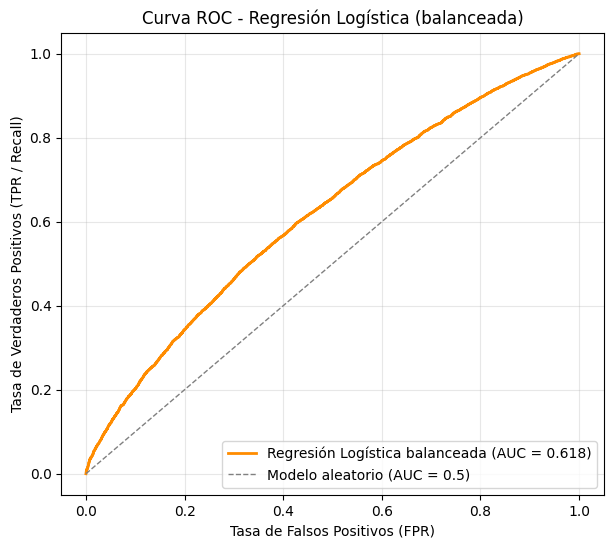

In [37]:
"""
  Curva ROC y AUC para el modelo de regesión Logistica
"""
y_proba = modelo_balanceado.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Regresión Logística balanceada (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Modelo aleatorio (AUC = 0.5)')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC - Regresión Logística (balanceada)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## **10.3 Random Forest**

In [23]:
"""
  Código para crear un modelo ensamblado con arboles de desición aleatorios
  Usamos class_weight='balanced' para mitigar el problema del desbalance de clases
"""
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,              # Limita la profundidad para evitar sobreajuste
    min_samples_split=10,      # Mínimo de muestras para dividir un nodo
    min_samples_leaf=4,        # Mínimo de muestras en las hojas terminales
    max_features='sqrt',       # Raíz cuadrada de las features por división (por defecto, ideal para alta dimensionalidad)
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1                 # Todos los procesadores disponibles
)
# Entrenar el modelo con los datos de entrenamiento
rf.fit(X_train, y_train)

# Hacer predicciones con el conjunto de prueba
y_pred_rf = rf.predict(X_test)

# Evaluar los resultados
print("Exactitud (Accuracy) - Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_rf))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_rf))


Exactitud (Accuracy) - Random Forest: 0.6219155766374395

Matriz de Confusión:
 [[8272 4212]
 [3679 4708]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.69      0.66      0.68     12484
           1       0.53      0.56      0.54      8387

    accuracy                           0.62     20871
   macro avg       0.61      0.61      0.61     20871
weighted avg       0.63      0.62      0.62     20871



F1 Score: 0.5440573178482695
ROC-AUC: 0.6573162998823303


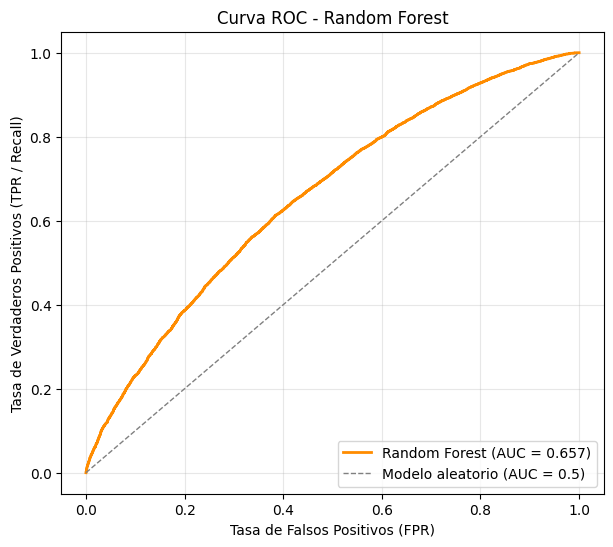

In [38]:
"""
  El codigo hace predicciones al modelo
  que calcula la probabilidad de la clase positiva y crea la curva ROC para el modelo
  Random Forest.
"""
y_proba_rf = rf.predict_proba(X_test)[:, 1]  # probabilidad de clase 1

f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)

print("F1 Score:", f1_rf)
print("ROC-AUC:", auc_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Modelo aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC - Random Forest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## **10.4 Modelo Gradient Boosting**

In [39]:
"""
  Código que crea el modelo ensamblado Gradient Boosting
  usamos la class_weight = 'balanced' para mitigar el desbalance de clases.
"""
gboost = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.08,         # Coeficiente de aprendizaje
    max_depth=3,
    subsample=0.8,              # entrena cada arbol con 80% de las muestras (reduce sobreajuste)
    min_samples_split=10,       # minimo de muestras para dividir un nodo
    min_samples_leaf=5,         # minimo de muestras en las hojas terminales
    max_features='sqrt',        # raiz cuadrada de las features por division
    validation_fraction=0.1,    # reserva 10% para validacion interna
    n_iter_no_change=10,        # detiene el entrenamiento si no mejora en 10 iteraciones
    random_state=42
)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
gboost.fit(X_train, y_train, sample_weight=sample_weights)

y_proba = gboost.predict_proba(X_test)[:, 1]

umbral_elegido = 0.5
y_pred_final = (y_proba >= umbral_elegido).astype(int)

print(f"Umbral utilizado: {umbral_elegido:.2f}")

Umbral utilizado: 0.50


              precision    recall  f1-score   support

           0       0.69      0.63      0.66     12484
           1       0.51      0.58      0.54      8387

    accuracy                           0.61     20871
   macro avg       0.60      0.60      0.60     20871
weighted avg       0.62      0.61      0.61     20871

ROC AUC: 0.6518405034538164
[[7849 4635]
 [3547 4840]]


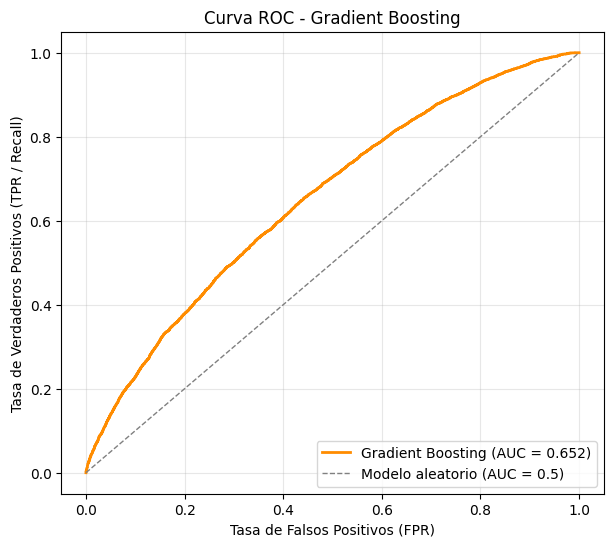

In [40]:
y_pred = gboost.predict(X_test)
y_proba = gboost.predict_proba(X_test)[:, 1]  # probabilidad de clase 1

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

y_proba =gboost.predict_proba(X_test)[:, 1]  # probabilidad de clase 1


fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Gradient Boosting (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Modelo aleatorio (AUC = 0.5)')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC - Gradient Boosting')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

## **10.6 Modelo de Red Neuronal**

In [41]:
"""
  Reinicializar y preprocesar 'df' específicamente para la sección de la Red Neuronal
"""

df = pd.read_csv(archivo)
df = df.replace("?", np.nan)


df = limpiar_df(df)
df = transformar_ordinales(df)
df = transformar_medicamentos_y_nominales(df)
df = transformar_target(df)

print("DataFrame 'df' reinicializado y preprocesado para la Red Neuronal.")
print("Dimensiones finales del DataFrame:", df.shape)

DataFrame 'df' reinicializado y preprocesado para la Red Neuronal.
Dimensiones finales del DataFrame: (69570, 69)


In [42]:
"""
   Preparación de datos para la Red Neuronal
"""

if "readmitted" not in df.columns:
    raise ValueError("La columna 'readmitted' no existe en el dataset")

y_nn = df["readmitted"]
X_nn = df.drop(columns=["readmitted"])


if 'y_train' in X_nn.columns:
    X_nn = X_nn.drop(columns=['y_train'])

# División en conjuntos de entrenamiento, validación y prueba

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_nn, test_size=0.2, stratify=y_nn, random_state=42
)
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_nn, y_train_nn, test_size=0.2, stratify=y_train_nn, random_state=42
)

print("Formas de los conjuntos de datos:")
print("X_train_nn:", X_train_nn.shape)
print("X_val_nn:", X_val_nn.shape)
print("X_test_nn:", X_test_nn.shape)

# Escalado de características
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train_nn)
X_val_nn = scaler_nn.transform(X_val_nn)
X_test_nn = scaler_nn.transform(X_test_nn)
print("\nDatos escalados correctamente.")

# Cálculo de pesos de clase para manejar el desbalance
class_weights_nn = compute_class_weight('balanced', classes=np.unique(y_train_nn), y=y_train_nn)
class_weight_dict_nn = {cls: f"{weight:.2f}" for cls, weight in enumerate(class_weights_nn)}
print("\nPesos de clase:", class_weight_dict_nn)

Formas de los conjuntos de datos:
X_train_nn: (44524, 68)
X_val_nn: (11132, 68)
X_test_nn: (13914, 68)

Datos escalados correctamente.

Pesos de clase: {0: '0.84', 1: '1.24'}


In [43]:
""" Definición del modelo de Red Neuronal
"""
model_nn = Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.003)), #0.001
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.003)), #0.001
    layers.Dense(1, activation='sigmoid')
])


In [44]:
""" Compilación del modelo
"""
model_nn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)

In [45]:
"""
  early_stop_nn es una técnica para detener el entrenamiento de la red neuronal si la pérdida de validación no mejora
  después de un número específico de épocas (patience), restaurando los mejores pesos encontrados.
"""
early_stop_nn = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

## **10.7 Entrenamiento del modelo neuronal***

In [46]:
# Entrenamiento del modelo
history_nn = model_nn.fit(
    X_train_nn, y_train_nn,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_nn, y_val_nn),
    class_weight=class_weight_dict_nn,
    callbacks=[early_stop_nn],
    shuffle=True,
    verbose=1
)

Epoch 1/100
1392/1392 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5519 - auc: 0.5614 - loss: 0.8097 - precision: 0.4497 - recall: 0.5145 - val_accuracy: 0.6120 - val_auc: 0.6113 - val_loss: 0.7358 - val_precision: 0.5258 - val_recall: 0.3534
Epoch 2/100
1392/1392 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5877 - auc: 0.6063 - loss: 0.7218 - precision: 0.4873 - recall: 0.4999 - val_accuracy: 0.6080 - val_auc: 0.6236 - val_loss: 0.6920 - val_precision: 0.5138 - val_recall: 0.4562
Epoch 3/100
1392/1392 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5913 - auc: 0.6161 - loss: 0.6923 - precision: 0.4922 - recall: 0.5350 - val_accuracy: 0.5917 - val_auc: 0.6248 - val_loss: 0.6799 - val_precision: 0.4929 - val_recall: 0.5514
Epoch 4/100
1392/1392 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5899 - auc: 0.6192 - loss: 0.6808 - precision: 0.4909 - recall: 0.5539 - val_accuracy: 0.5969 - val_auc: 0.6297 - val_loss: 0.6744 - val_precision: 0.4987 - val_recall: 0.5610
Epoch 5/100
1392/139

# **10.8 Curvas de aprendizaje**

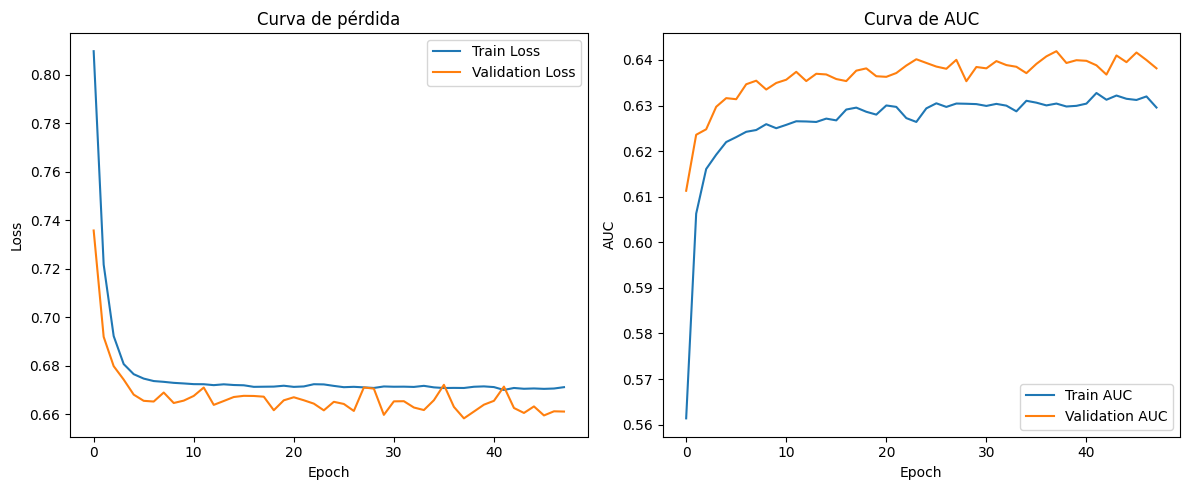

In [47]:
# Curvas de aprendizaje
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_nn.history['loss'], label='Train Loss')
plt.plot(history_nn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Curva de pérdida')

plt.subplot(1, 2, 2)
plt.plot(history_nn.history['auc'], label='Train AUC')
plt.plot(history_nn.history['val_auc'], label='Validation AUC')
plt.xlabel('Epoch'); plt.ylabel('AUC'); plt.legend(); plt.title('Curva de AUC')
plt.tight_layout()
plt.show()

## **Explicación de Curvas de Pérdida y AUC**

### **Curva de Pérdida (Loss Curve)**

La curva de pérdida es un gráfico que muestra cómo el valor de la **función de pérdida** del modelo cambia a lo largo de las épocas de entrenamiento. La función de pérdida (o función de costo) es una métrica que cuantifica qué tan bien se está desempeñando el modelo; valores más bajos indican un mejor ajuste.

*   **Loss (Train Loss)**: Representa la pérdida calculada sobre el conjunto de datos de entrenamiento en cada época. Es normal que esta pérdida disminuya a medida que el modelo aprende de los datos de entrenamiento.
*   **Validation Loss (Val Loss)**: Representa la pérdida calculada sobre un conjunto de datos de validación (no vistos durante el entrenamiento de cada época). Esta curva es crucial para detectar el **sobreajuste (overfitting)**. Si la pérdida de entrenamiento sigue disminuyendo mientras la pérdida de validación comienza a aumentar o se estanca, es una señal de que el modelo está aprendiendo patrones específicos del conjunto de entrenamiento que no se generalizan bien a datos nuevos.

El objetivo es que ambas curvas disminuyan y se mantengan cerca una de la otra, lo que indica un buen aprendizaje y generalización.

### **Curva AUC (Area Under the Curve - ROC Curve)**

La curva AUC (o más precisamente, la **Curva ROC y su Área bajo la Curva**) es una métrica de evaluación utilizada para modelos de clasificación, especialmente en problemas con clases desbalanceadas. La curva ROC (Receiver Operating Characteristic) grafica la **Tasa de Verdaderos Positivos (TPR)** contra la **Tasa de Falsos Positivos (FPR)** en varios umbrales de clasificación.

*   **TPR (Sensibilidad o Recall)**: Proporción de positivos reales que se identificaron correctamente.
*   **FPR (1 - Especificidad)**: Proporción de negativos reales que se identificaron incorrectamente como positivos.

**AUC**: Es el área bajo la curva ROC. El valor del AUC va de 0 a 1:

*   **AUC = 1**: Indica un clasificador perfecto que distingue perfectamente entre las clases.
*   **AUC = 0.5**: Indica un clasificador tan bueno como un modelo aleatorio (no tiene capacidad de discriminación).
*   **AUC < 0.5**: Indica un clasificador peor que el aleatorio (generalmente, esto significa que el modelo está invirtiendo las predicciones y podría corregirse).

Un AUC más alto significa que el modelo es mejor para distinguir entre las clases positiva y negativa. Es una métrica robusta para evaluar modelos en escenarios de desbalance de clases, ya que no se ve tan afectada por la proporción de clases como la precisión (accuracy).

In [48]:
"""
   Predicción de probabilidades en el conjunto de prueba
   y_pred_prob_nn = model_nn.predict(X_test_nn).ravel(),
   Cálculo del mejor umbral
"""
y_pred_prob_nn = model_nn.predict(X_test_nn).ravel()

# Cálculo del mejor umbral con Precision-Recall Curve
precisions_nn, recalls_nn, thresholds_nn = precision_recall_curve(y_test_nn, y_pred_prob_nn)
f1_scores_nn = 2 * (precisions_nn * recalls_nn) / (precisions_nn + recalls_nn + 1e-9)
best_threshold_nn = thresholds_nn[np.argmax(f1_scores_nn)]
print(f"Mejor umbral encontrado (maximizando F1-score): {best_threshold_nn:.4f}")

435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mejor umbral encontrado (maximizando F1-score): 0.3701



Matriz de Confusión con umbral ajustado:


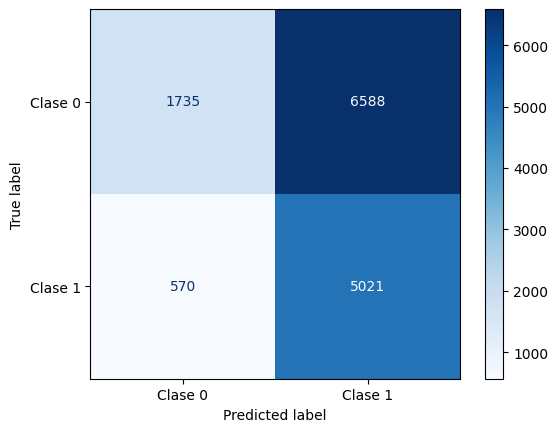


Reporte de Clasificación con umbral ajustado:
              precision    recall  f1-score   support

     Clase 0       0.75      0.21      0.33      8323
     Clase 1       0.43      0.90      0.58      5591

    accuracy                           0.49     13914
   macro avg       0.59      0.55      0.46     13914
weighted avg       0.62      0.49      0.43     13914



In [49]:
"""
Evaluación con el umbral ajustado

"""
y_pred_ajustado_nn = (y_pred_prob_nn >= best_threshold_nn).astype(int)

print("\nMatriz de Confusión con umbral ajustado:")
cm_nn = confusion_matrix(y_test_nn, y_pred_ajustado_nn)
ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['Clase 0', 'Clase 1']).plot(cmap='Blues')
plt.show()

print("\nReporte de Clasificación con umbral ajustado:")
print(classification_report(y_test_nn, y_pred_ajustado_nn, target_names=['Clase 0', 'Clase 1']))

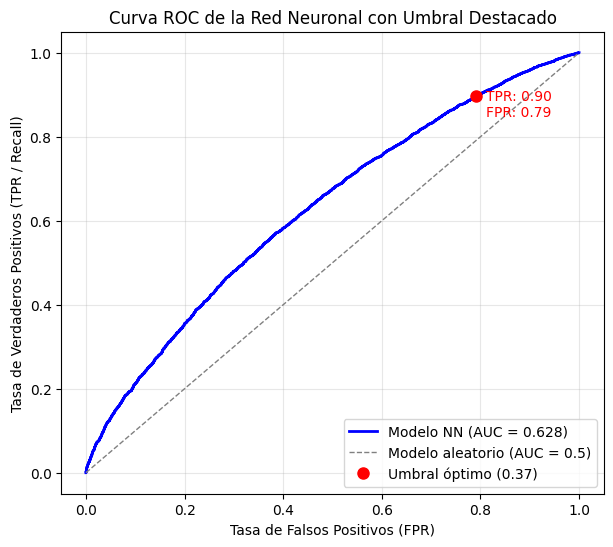

In [50]:
"""

Curva ROC con umbral destacado

"""
fpr_nn, tpr_nn, thresholds_roc_nn = roc_curve(y_test_nn, y_pred_prob_nn)
auc_score_nn = roc_auc_score(y_test_nn, y_pred_prob_nn)

# Encontrar el punto en la curva ROC más cercano al mejor umbral
threshold_index_nn = np.argmin(np.abs(thresholds_roc_nn - best_threshold_nn))
fpr_at_threshold_nn = fpr_nn[threshold_index_nn]
tpr_at_threshold_nn = tpr_nn[threshold_index_nn]

plt.figure(figsize=(7, 6))
plt.plot(fpr_nn, tpr_nn, color='blue', lw=2, label=f'Modelo NN (AUC = {auc_score_nn:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Modelo aleatorio (AUC = 0.5)')

# Marcar el punto correspondiente al umbral elegido
plt.plot(fpr_at_threshold_nn, tpr_at_threshold_nn, 'o', color='red', markersize=8,
         label=f'Umbral óptimo ({best_threshold_nn:.2f})')
plt.text(fpr_at_threshold_nn + 0.02, tpr_at_threshold_nn - 0.05,
         f'TPR: {tpr_at_threshold_nn:.2f}\nFPR: {fpr_at_threshold_nn:.2f}',
         color='red', fontsize=10)

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Curva ROC de la Red Neuronal con Umbral Destacado')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## **10.5 Comparacion de modelos**

| Metrica | Regresion Logistica | Random Forest | Gradient Boosting | Red Neuronal |
|---|---|---|---|---|
| Accuracy | 0.595 | 0.622 | 0.61 | 0.50 |
| ROC-AUC | 0.618 | 0.657 | 0.652 | 0.640 |
| Precision (clase 1) | 0.50 | 0.53 | 0.51 | 0.44 |
| Recall (clase 1) | 0.53 | 0.56 | 0.58 | 0.89 |
| F1-score (clase 1) | 0.51 | 0.54 | 0.54 | 0.59 |


---


1. **Random Forest** obtuvo el mejor ROC-AUC (0.657), seguido de cerca por **Gradient Boosting** (0.652) y la **Red Neuronal** (0.640). Todos superan claramente a **Regresion Logistica** (0.618), confirmando que las relaciones no lineales entre variables aportan valor predictivo adicional.

2. La **Red Neuronal** logró el mejor recall de la clase 1 (0.89) con un umbral ajustado de 0.369, priorizando significativamente la detección de casos reales de readmisión, aunque con una precisión (0.44) y exactitud general (0.50) más bajas en comparación. Este alto recall resulta en el F1-score más alto (0.59) para la clase positiva.

3. **Gradient Boosting** logró un buen balance con un recall de la clase 1 de 0.58.

Los cuatro modelos se ubican en el rango de AUC 0.61 a 0.66, consistente con el techo de desempeño de 0.65 a 0.70 reportado en la literatura para este dataset.

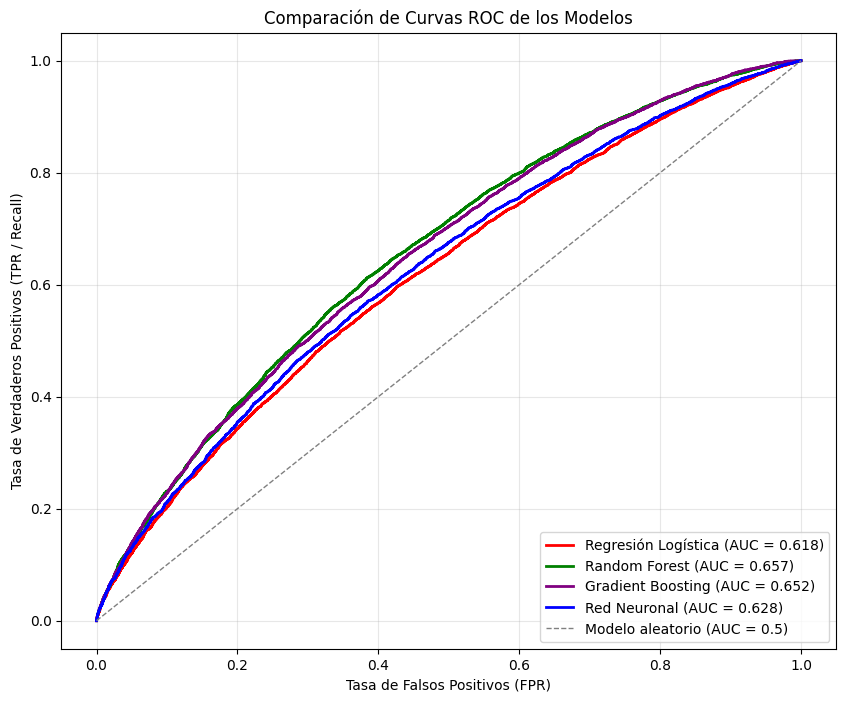

In [51]:
"""
   Comparación de las curvas ROC de los modelos.

"""

y_proba_lr = modelo_balanceado.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)


fpr_gb, tpr_gb, auc_gb = fpr, tpr, auc                # Gradient Boosting
fpr_rf, tpr_rf, auc_rf = fpr_rf, tpr_rf, auc_rf       # Random Forest
fpr_nn, tpr_nn, auc_nn = fpr_nn, tpr_nn, auc_score_nn # Red Neuronal

plt.figure(figsize=(10, 8))

plt.plot(fpr_lr, tpr_lr, color='red', lw=2, label=f'Regresión Logística (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_gb, tpr_gb, color='purple', lw=2, label=f'Gradient Boosting (AUC = {auc_gb:.3f})')
plt.plot(fpr_nn, tpr_nn, color='blue', lw=2, label=f'Red Neuronal (AUC = {auc_nn:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Modelo aleatorio (AUC = 0.5)')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.title('Comparación de Curvas ROC de los Modelos')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## **11. Conclusiones y limitaciones**

## Conclusiones

**Sobre el resultado obtenido**

Los cuatro modelos entrenados (Regresión Logística, Random Forest, Gradient Boosting y Red Neuronal) alcanzaron un ROC-AUC entre 0.618 y 0.657. **Random Forest** fue el de mejor desempeño en términos de AUC general (0.657), seguido muy de cerca por **Gradient Boosting** (AUC 0.652) y la **Red Neuronal** (AUC 0.640). **Regresión Logística**, al ser el modelo más simple, obtuvo el resultado más bajo (AUC 0.618), confirmando que existen relaciones no lineales entre las variables que los modelos de ensamble y las redes neuronales logran capturar mejor.

La **Red Neuronal** se destacó por lograr el **recall más alto para la clase positiva (0.89)** al ajustar su umbral de decisión a 0.369. Esto significa que la red neuronal es la más efectiva para identificar pacientes que realmente serán readmitidos, lo cual es crucial en un contexto clínico donde la detección temprana es prioritaria, a pesar de que esto implicó una menor precisión (0.44) y exactitud general (0.50). Su F1-score para la clase positiva (0.59) fue el más alto entre todos los modelos, reflejando su capacidad para equilibrar precisión y recall en la detección de la clase minoritaria.

**Sobre la dificultad del dataset**

Estos resultados son consistentes con el techo de desempeño reportado ampliamente en la literatura para este dataset (AUC 0.65 a 0.70), incluso en estudios que emplean algoritmos más sofisticados como XGBoost o redes neuronales profundas. Esto confirma que la limitación no proviene de los algoritmos utilizados, sino del poder predictivo disponible en las variables: el reingreso hospitalario depende de factores como adherencia al tratamiento, apoyo social o comorbilidades no registradas, que este dataset no captura.

**Sobre la depuración metodológica**

Durante el desarrollo del proyecto se identificó y corrigió un error metodológico relevante: las columnas encounter_id y patient_nbr, simples identificadores sin valor clínico, se encontraban incluidas como variables predictoras. Al eliminarlas, el dataset pasó de 71 a 68 columnas, y los modelos fueron reentrenados sobre datos limpios. Este ajuste refuerza la validez de los resultados finales, al asegurar que el desempeño de los modelos no depende de información sin sentido predictivo real.

**Sobre el manejo del desbalance de clases**

Dado que la clase de pacientes readmitidos es minoritaria, los modelos se entrenaron utilizando `class_weight` balanceado. Adicionalmente, en Gradient Boosting se ajustó el umbral de decisión de 0.5 a 0.35, y en la Red Neuronal a 0.369, priorizando la detección de casos reales de readmisión (recall) sobre la precisión general, ya que en un contexto clínico un falso negativo (no anticipar una readmisión real) resulta más costoso que un falso positivo.

**Sobre el análisis de correlación**

La mayoría de variables individuales mostraron correlación lineal débil con la variable objetivo, lo cual no indica falta de utilidad, sino que sus relaciones con la readmisión son no lineales o dependen de interacciones entre variables, patrones que los modelos de ensamble y la Red Neuronal logran aprovechar mejor que un análisis de correlación simple.

**Trabajo futuro**

Futuras mejoras podrían enfocarse en la ingeniería de nuevas variables, como combinaciones de diagnósticos y medicamentos, o el uso de técnicas de agrupación para variables como `medical_specialty`, en lugar de continuar ajustando los hiperparámetros de los algoritmos actuales, dado que el techo de desempeño parece estar determinado principalmente por el poder predictivo de las variables disponibles.